# plot points

In [9]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve, splu
from scipy.spatial import cKDTree
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import time

dtype_torch = torch.float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 1e-12
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(31.6228)**2 * x**2)
        output = self.input_layer(x)
        output = torch.sigmoid(output) * 2 * torch.pi
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    # nn.init.uniform_(m.bias, -np.pi, np.pi)
                    nn.init.uniform_(m.bias, -0, 0)

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

def poly1D(x,order):  # (nj,1) -> (nj,order+1)
    if x.ndim == 1:
        x = x[:,None]
    return np.concatenate([x**k for k in range(order+1)], axis=1)

def lap_poly1D(x,order): # (nj,1) -> (nj,order+1)
    if x.ndim == 1:
        x = x[:,None]
    Norder = order + 1
    out = np.zeros((len(x), Norder))
    for k in range(2, order+1):
        out[:,k] = k*(k-1) * x[:, 0]**(k-2)
    return out

def grad_poly1D(x, order):
    x = np.asarray(x).reshape(-1, 1)
    out = np.zeros((x.shape[0], order + 1), dtype=np.float64)
    for k in range(1, order + 1):
        out[:, k] = (k * (x[:, 0] ** (k - 1)))
    return out

def shepard_weights_1d(x, ptch_C, ptch_R):
    """
    x: (M, 1) evaluation points
    ptch_C: (Nc, 1) patch centers
    ptch_R: (Nc,) patch radii
    Returns W, Wx, Wxx of shape (M, Nc)
    """
    x = np.asarray(x).flatten()
    ptch_C = np.asarray(ptch_C).flatten()
    ptch_R = np.asarray(ptch_R).flatten()

    M, Nc = len(x), len(ptch_C)
    
    diff = x[:, None] - ptch_C[None, :]  # M x Nc
    r = np.abs(diff)
    r_scaled = r / ptch_R[None, :]

    # Wendland C2 1D
    mask = (r_scaled <= 1.0).astype(float)
    phi = (4 * r_scaled + 1) * (1 - r_scaled)**4 * mask

    S = np.sum(phi, axis=1, keepdims=True)
    S[S == 0] = 1e-14
    W = phi / S

    # First Derivative Wx
    dphi_dr = -20 * r_scaled * (1 - r_scaled)**3 * mask
    sgn = np.sign(diff)
    sgn[sgn == 0] = 1.0  # Handle exact centers gracefully
    
    phi_x = (dphi_dr / ptch_R[None, :]) * sgn
    Sx = np.sum(phi_x, axis=1, keepdims=True)
    Wx = (phi_x * S - phi * Sx) / (S**2)

    # Second Derivative Wxx
    d2phi_dr2 = (60 * r_scaled * (1 - r_scaled)**2 - 20 * (1 - r_scaled)**3) * mask
    phi_xx = (d2phi_dr2 / (ptch_R[None, :]**2)) * (sgn**2)
    Sxx = np.sum(phi_xx, axis=1, keepdims=True)

    Wxx = ((phi_xx * S - phi * Sxx) / (S**2) - 
           2 * (phi_x * S - phi * Sx) * Sx / (S**3))

    return W, Wx, Wxx

def laplacian_phi_wrt_y_1d(phi_net, y, X, eps=1e-8):
    """
    1D Parameters
    ----------
    y : (n_j,1) or (n_j,)
    X : (K,1) or (K,)
    
    Returns
    -------
    phi_vals : (n_j, K)
    dphi_dy  : (n_j, K)
    d2phi_dy2: (n_j, K)
    """
    # -------- reshape --------
    y = torch.tensor(y, dtype=torch.float64, device=device).view(-1,1)   # (n_j,1)
    X = torch.tensor(X, dtype=torch.float64, device=device).view(1,-1)   # (1,K)

    # -------- pairwise diff --------
    diff = y - X                         # (n_j, K)
    r = torch.abs(diff)                  # (n_j, K)
    r = r.clamp(min=eps)
    r.requires_grad_(True)
    # -------- forward --------
    phi_vals = phi_net(r)         # (n_j, K)

    # -------- φ'(r) --------
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True
    )[0]   # (n_j, K)

    # -------- φ''(r) --------
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False
    )[0]   # (n_j, K)
    sgn = torch.sign(diff)
    sgn[sgn == 0] = 1.0
    grad_y = dphi_dr * sgn
    lap_y = d2phi_dr2

    return (
        phi_vals.detach().cpu().numpy(),
        grad_y.detach().cpu().numpy(),
        lap_y.detach().cpu().numpy()
    )

def shepard_weights_1d(x, patch_c, patch_r):
    x = np.asarray(x).reshape(-1, 1)
    patch_c = np.asarray(patch_c).reshape(1, -1)
    patch_r = np.asarray(patch_r).reshape(1, -1)

    diff = x - patch_c
    rr = np.abs(diff)
    r_scaled = rr / patch_r

    # Wendland C2: (1-r)^4 (4r+1), r<=1
    phi = (4.0 * r_scaled + 1.0) * (1.0 - r_scaled) ** 4
    phi[r_scaled > 1.0] = 0.0

    s = np.sum(phi, axis=1, keepdims=True)
    s[s == 0.0] = 1e-14
    w = phi / s

    # first derivative
    dphi_dr = -20.0 * r_scaled * (1.0 - r_scaled) ** 3
    dphi_dr[r_scaled > 1.0] = 0.0

    sgn = np.sign(diff)
    sgn[sgn == 0.0] = 1.0
    phi_x = (dphi_dr / patch_r) * sgn

    sx = np.sum(phi_x, axis=1, keepdims=True)
    wx = (phi_x * s - phi * sx) / (s ** 2)

    # second derivative
    d2phi_dr2 = 60.0 * r_scaled * (1.0 - r_scaled) ** 2 - 20.0 * (1.0 - r_scaled) ** 3
    d2phi_dr2[r_scaled > 1.0] = 0.0

    phi_xx = (d2phi_dr2 / (patch_r ** 2)) * (sgn ** 2)
    sxx = np.sum(phi_xx, axis=1, keepdims=True)

    wxx = (phi_xx * s - phi * sxx) / (s ** 2) - 2.0 * (phi_x * s - phi * sx) * sx / (s ** 3)
    return w, wx, wxx


def rfm_fd_pou_poly_solve_heat_1d(kap,ptch,phi_net,X,Yin,Yb,t,tau,f_func,g_func,u0_func,reg,order):
    """
    1D heat equation solver:
      u_t = kap * u_xx + f(x,t)
    with Dirichlet BC and BDF2 in time.
    X:   (N,1)  source points
    Yin: (M1,1) interior points
    Yb:  (M2,1) boundary points
    """
    patch_c = np.asarray(ptch["C"]).reshape(-1,1)
    patch_r = np.asarray(ptch["R"]).reshape(-1,1)

    X = np.asarray(X).reshape(-1, 1)
    Yin = np.asarray(Yin).reshape(-1, 1)
    Yb = np.asarray(Yb).reshape(-1, 1)
    Y = np.concatenate([Yin, Yb])

    Nt = t.shape[-1]
    N = X.shape[0]
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2
    Np = patch_c.shape[0]

    # Construct RHS
    RHS = np.zeros((M,1))
    f_val = f_func(Yin, t) if callable(f_func) else f_func # (M1,NT)
    g_val = g_func(Yb, t) if callable(g_func) else g_func  # (2, NT)
    u0 = u0_func(Y) if callable(u0_func) else u0_func      # (M,1)

    W, Wx, Wxx = shepard_weights_1d(Y, patch_c, patch_r)

    LBDF1 = lil_matrix((M, N), dtype=np.float64)
    LBDF2 = lil_matrix((M, N), dtype=np.float64)
    LI = lil_matrix((M, N), dtype=np.float64)

    dist_XC = np.abs(X[:, None] - patch_c[None, :])
    dist_YC = np.abs(Y[:, None] - patch_c[None, :])

    for j in range(Np):
        idx_X = np.where(dist_XC[:, j] <= patch_r[j])[0]
        idx_Y = np.where(dist_YC[:, j] <= patch_r[j])[0]
        idx_Yin = idx_Y[idx_Y < M1]
        idx_Yb = idx_Y[idx_Y >= M1]

        if idx_X.size == 0:
            continue

        Xk = X[idx_X]
        Yk = Y[idx_Y]
        Yk_in = Y[idx_Yin]

        h_local = patch_r[j]
        xc = patch_c[j]
        Xk = (Xk - xc[None, :]) / h_local
        Yk = (Yk - xc[None, :]) / h_local
        Yk_in = (Yk_in - xc[None, :]) / h_local

        nj = Xk.shape[0]
        Mk = Yk.shape[0]
        Mk_1 = Yk_in.shape[0]

        # AP = [[Phi_jj, Pj], [Pj^T, 0]]
        dist_ZZ = Xk[:, None] - Xk[None, :]
        Phi_jj, _, _ = laplacian_phi_wrt_y_1d(phi_net, Xk, Xk, eps=1e-8)
        Pj = poly1D(Xk, order)  # (nj, order+1)

        AP_top = np.concatenate([Phi_jj, Pj], axis=1)
        AP_bottom = np.concatenate([Pj.T, np.zeros((order + 1, order + 1))], axis=1)
        AP = np.concatenate([AP_top, AP_bottom], axis=0)
        AP = AP + reg * np.eye(AP.shape[0])
        # print("nj", nj, "AP shape:", AP.shape)
        # RHS blocks
        phi_YX, dxphiYX, d2phiYX = laplacian_phi_wrt_y_1d(phi_net, Yk, Xk, eps=1e-8) # (Mk, nj)
        dxphi = dxphiYX[:Mk_1, :]/h_local  # (Mk_1, nj)
        d2phi = d2phiYX[:Mk_1, :]/h_local**2 # (Mk_1, nj)

        Py = poly1D(Yk, order)                      # (Mk, order+1)
        dxP = grad_poly1D(Yk_in, order)/h_local     # (Mk_1, order+1)
        d2p = lap_poly1D(Yk_in, order)/h_local**2   # (Mk_1, order+1)

        RHS_ide = np.concatenate([phi_YX.T, Py.T], axis=0)   # (nj+order+1, Mk)
        RHS_gradx = np.concatenate([dxphi.T, dxP.T], axis=0) # (nj+order+1, Mk_1)
        RHS_lap = np.concatenate([d2phi.T, d2p.T], axis=0)   # (nj+order+1, Mk_1)

        W_all = np.linalg.solve(AP, np.concatenate([RHS_lap, RHS_gradx, RHS_ide], axis=1))

        w_lap = W_all[:, :Mk_1]
        w_gradx = W_all[:, Mk_1 : 2 * Mk_1]
        w_ide = W_all[:, 2 * Mk_1:]
        # print("w_lap shape:", w_lap.shape,"w_gradx shape:", w_gradx.shape,"w_ide shape:", w_ide.shape)
        win = W[idx_Yin, j][None, :]
        win_gradx = Wx[idx_Yin, j][None, :]
        win_lap = Wxx[idx_Yin, j][None, :]  #(1,nj)

        Laplace = (
            2.0 * win_gradx * w_gradx[:nj, :Mk_1]
            + win * w_lap[:nj, :Mk_1]
            + win_lap * w_ide[:nj, :Mk_1]
        )
        I = win * w_ide[:nj, :Mk_1]

        wbc = W[idx_Yb, j][None, :]
        Op_bc = wbc * w_ide[:nj, Mk_1:]

        wvec = W[idx_Y, j][None, :]
        IDE = wvec * w_ide[:nj, :]

        LBDF1[np.ix_(idx_Yin, idx_X)] = LBDF1[np.ix_(idx_Yin, idx_X)] + (I - kap * tau * Laplace).T
        LBDF2[np.ix_(idx_Yin, idx_X)] = LBDF2[np.ix_(idx_Yin, idx_X)] + (3.0 * I - 2.0 * kap * tau * Laplace).T

        if idx_Yb.size > 0:
            LBDF1[np.ix_(idx_Yb, idx_X)] = LBDF1[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF2[np.ix_(idx_Yb, idx_X)] = LBDF2[np.ix_(idx_Yb, idx_X)] + Op_bc.T

        LI[np.ix_(idx_Y, idx_X)] = LI[np.ix_(idx_Y, idx_X)] + IDE.T

    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()
    LI = LI.tocsr()
    cond_LI = np.linalg.cond(LI.todense())
    print("cond(LI) =", cond_LI)
    cond_LBDF1 = np.linalg.cond(LBDF1.todense())
    print("cond(LBDF1) =", cond_LBDF1)
    cond_LBDF2 = np.linalg.cond(LBDF2.todense())
    print("cond(LBDF2) =", cond_LBDF2)

    U = np.zeros((M, Nt), dtype=np.float64)
    U[:, 0:1] = u0
    print("g_val.shape",g_val.shape)
    U[M1:, :] = g_val

    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]  # (M,1)
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
        U[:M1,1:2] = LI[:M1, :] @ alpha_1
        U[M1:,1:2]  = g_val[:,1:2]
        # BDF2
        LU = splu(LBDF2.tocsc())
        for i in range(1,Nt-1):  # Nt-2
            right1 = LI @ (4 * alpha_1 - alpha_0)
            rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
            alpha_2 = LU.solve(RHS)
            U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
            alpha_0 = alpha_1
            alpha_1 = alpha_2
    else:
        print("M $\neq$ N. Please use QR.")
        
    return U,LBDF1,LBDF2,LI

t.shape (1, 101) u_true.shape (101, 101)
cond(LI) = 1.0000000022148503
cond(LBDF1) = 1.0040820092802427
cond(LBDF2) = 3.0041559147522587
g_val.shape (2, 101)
p = 3; L infity error in u_rfmfd: 1.082e-06
p = 3; Relative L2 error in u_rfmfd: 7.047e-05


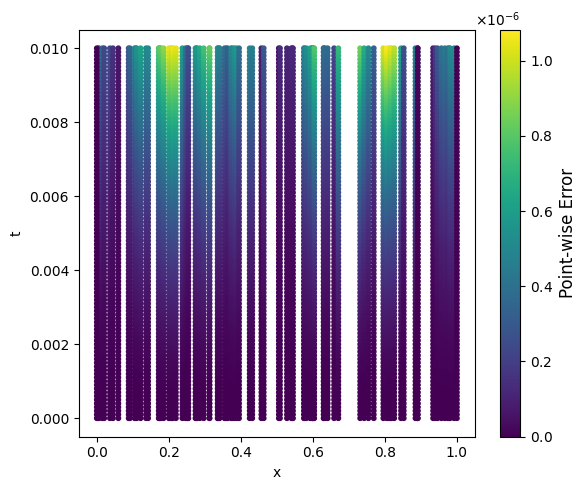

In [10]:

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(1, hidden_size, 1).to(device) #
Phi.initi()
Phi = Phi.double()

# patch settings
P = 11
C = np.linspace(0.0, 1.0, P)
h_patch = C[1] - C[0]
R = 1.5 * h_patch * np.ones(P)
ptch = {"C": C, "R": R}

# spatio-temporal nodes
tau = 1e-4
T = 1e-2

Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)[None,:]

Yin = np.sort(np.random.rand(Nt - 2))[:,None]

Yb = np.array([[0.0], [1.0]])
X = np.concatenate([Yin, Yb], axis=0)
Y = X.copy()
kap = 0.01

h = fill_distance(X)


u_func = lambda x, t: 0.9 / (0.04 * np.pi**2) * np.sin(2.0 * np.pi * x) * (1.0 - np.exp(-0.04 * np.pi**2 * t))
f_func = lambda x, t: 0.9 * np.sin(2.0 * np.pi * x) + 0.0 * x * t
g_func = lambda x, t: 0.0 * x * t
u0_func = lambda x: 0.0 * x

reg = 1e-13
order = 3

# Neural basis
phi_net = PhiNet(input_size=1, hidden_size=50, output_size=1).to(device=device, dtype=dtype_torch)
phi_net.initi()
phi_net.eval()


u_true = u_func(Y,t)
print("t.shape", t.shape, "u_true.shape",u_true.shape)

U, LBDF1, LBDF2, LI = rfm_fd_pou_poly_solve_heat_1d(kap,ptch,phi_net,X,Yin,Yb,t,tau,f_func,g_func,u0_func,reg,order)

error = np.abs(U - u_true)


print(f'p = {order}; L infity error in u_rfmfd: {error.max().item():.3e}')
error_u = relative_l2(U, u_true)
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u.item():.3e}')

Xg, Tg = np.meshgrid(Y, t, indexing='ij')
x = Xg.ravel()
tt = Tg.ravel()
err = error.ravel()

plt.figure(figsize=(6,5))
sc = plt.scatter(x, tt, c=err, cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('t')
plt.tight_layout()
# plt.savefig(f'./result/heat_rfmfd_p={order}_200_error.eps', bbox_inches='tight')
plt.show()


$Operator learning$

In [11]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import spsolve
from scipy.linalg import cholesky, solve_triangular
from scipy.linalg import lu_factor, lu_solve

def wls_chol_rowmax(A, b, reg=0.0):
    """
    WLS_CHOL_ROWMAX
    Solve weighted least squares using Cholesky factorization
        min_x || W (A x - b) ||_2^2
    where weights w_i = 1 / (max_j |A_ij| + eps)
    Parameters
    ----------
    A : scipy.sparse matrix, shape (M, N)
        Sparse system matrix
    b : ndarray, shape (M,)
        Right-hand side
    reg : float, optional
        Tikhonov regularization parameter (default 0)
    Returns
    -------
    x : ndarray, shape (N,)
        Solution vector
    info : dict
        Diagnostic information
    """
    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")
    A = A.tocsr()

    b = np.asarray(b,dtype=np.float64).squeeze(-1) 
    M, N = A.shape
    assert b.shape[0] == M, "Dimension mismatch"
    # -------------------------------------------------
    # Step 1: row-wise max for sparse matrix
    # -------------------------------------------------
    # Equivalent to MATLAB: full(max(abs(A), [], 2))
    # row_max = np.asarray(np.abs(A).max(axis=1)).ravel()   # (M,) ndarray
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    eps0 = 1e-12
    w = 10 / (row_max + eps0)   # (M,)
    # -------------------------------------------------
    # Step 2: apply weights implicitly
    # -------------------------------------------------
    # Aw = W * A, bw = W * b
    W = sp.diags(w, offsets=0, format='csr')
    Aw = W @ A
    bw = w * b
  
    # -------------------------------------------------
    # Step 3: normal equations
    # -------------------------------------------------
    AtA = Aw.T @ Aw    # (N, N), sparse SPD (hopefully)
    Atb = Aw.T @ bw

    if reg > 0:
        AtA = AtA + reg * sp.eye(N, format='csr')

    # -------------------------------------------------
    # Step 4: Cholesky solve
    # -------------------------------------------------
    try:
        # scipy 对稀疏 Cholesky 没有内建 chol
        # spsolve 等价于 MATLAB 的 "\" 退化路径
        x = spla.spsolve(AtA, Atb)
        flag = 0
    except Exception:
        print("Warning: linear solve failed.")
        x = spla.lsmr(AtA, Atb)[0]
        flag = 1
    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    try:
        cond_est = spla.onenormest(AtA) * spla.onenormest(spla.inv(AtA))
    except Exception:
        cond_est = np.nan

    info = {
        "flag": flag,
        "row_max_min": row_max.min(),
        "row_max_max": row_max.max(),
        "cond_est": cond_est
    }
    return x, info

# solve multi-dimension of f_func
def rfm_fd_pou_poly_solve_heat_1d(kap,ptch,phi_net,X,Yin,Yb,t,tau,f_func,g_func,u0_func,reg,order):
    """
    1D heat equation solver:
      u_t = kap * u_xx + f(x,t)
    with Dirichlet BC and BDF2 in time.
    X:   (N,1)  source points
    Yin: (M1,1) interior points
    Yb:  (M2,1) boundary points
    """
    patch_c = np.asarray(ptch["C"]).reshape(-1,1)
    patch_r = np.asarray(ptch["R"]).reshape(-1,1)

    X = np.asarray(X).reshape(-1, 1)
    Yin = np.asarray(Yin).reshape(-1, 1)
    Yb = np.asarray(Yb).reshape(-1, 1)
    Y = np.concatenate([Yin, Yb])

    Nt = t.shape[-1]
    N = X.shape[0]
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2
    Np = patch_c.shape[0]

    # Construct RHS
    RHS = np.zeros((M,1))
    f_val = f_func(Yin, t) if callable(f_func) else f_func # (M1,NT)
    g_val = g_func(Yb, t) if callable(g_func) else g_func  # (2, NT)
    u0 = u0_func(Y) if callable(u0_func) else u0_func      # (M,1)

    W, Wx, Wxx = shepard_weights_1d(Y, patch_c, patch_r)

    LBDF1 = lil_matrix((M, N), dtype=np.float64)
    LBDF2 = lil_matrix((M, N), dtype=np.float64)
    LI = lil_matrix((M, N), dtype=np.float64)

    dist_XC = np.abs(X[:, None] - patch_c[None, :])
    dist_YC = np.abs(Y[:, None] - patch_c[None, :])
    start_time = time.time()
    for j in range(Np):
        idx_X = np.where(dist_XC[:, j] <= patch_r[j])[0]
        idx_Y = np.where(dist_YC[:, j] <= patch_r[j])[0]
        idx_Yin = idx_Y[idx_Y < M1]
        idx_Yb = idx_Y[idx_Y >= M1]

        if idx_X.size == 0:
            continue

        Xk = X[idx_X]
        Yk = Y[idx_Y]
        Yk_in = Y[idx_Yin]

        h_local = patch_r[j]
        xc = patch_c[j]
        Xk = (Xk - xc[None, :]) / h_local
        Yk = (Yk - xc[None, :]) / h_local
        Yk_in = (Yk_in - xc[None, :]) / h_local
        

        nj = Xk.shape[0]
        Mk = Yk.shape[0]
        Mk_1 = Yk_in.shape[0]

        # AP = [[Phi_jj, Pj], [Pj^T, 0]]
        dist_ZZ = Xk[:, None] - Xk[None, :]
        Phi_jj, _, _ = laplacian_phi_wrt_y_1d(phi_net, Xk, Xk, eps=1e-13)
        Pj = poly1D(Xk, order)  # (nj, order+1)

        AP_top = np.concatenate([Phi_jj, Pj], axis=1)
        AP_bottom = np.concatenate([Pj.T, np.zeros((order + 1, order + 1))], axis=1)
        AP = np.concatenate([AP_top, AP_bottom], axis=0)
        AP = AP + reg * np.eye(AP.shape[0])
        print("nj", nj)
        # RHS blocks
        phi_YX, dxphiYX, d2phiYX = laplacian_phi_wrt_y_1d(phi_net, Yk, Xk, eps=1e-13) # (Mk, nj)
        dxphi = dxphiYX[:Mk_1, :]/h_local # (Mk_1, nj)
        d2phi = d2phiYX[:Mk_1, :]/h_local**2 # (Mk_1, nj)

        Py = poly1D(Yk, order)                      # (Mk, order+1)
        dxP = grad_poly1D(Yk_in, order)/h_local     # (Mk_1, order+1)
        d2p = lap_poly1D(Yk_in, order)/h_local**2   # (Mk_1, order+1)

        RHS_ide = np.concatenate([phi_YX.T, Py.T], axis=0)   # (nj+order+1, Mk)
        RHS_gradx = np.concatenate([dxphi.T, dxP.T], axis=0) # (nj+order+1, Mk_1)
        RHS_lap = np.concatenate([d2phi.T, d2p.T], axis=0)   # (nj+order+1, Mk_1)

        W_all = np.linalg.solve(AP, np.concatenate([RHS_lap, RHS_gradx, RHS_ide], axis=1))

        w_lap = W_all[:, :Mk_1]
        w_gradx = W_all[:, Mk_1 : 2 * Mk_1]
        w_ide = W_all[:, 2 * Mk_1:]
        # print("w_lap shape:", w_lap.shape,"w_gradx shape:", w_gradx.shape,"w_ide shape:", w_ide.shape)
        win = W[idx_Yin, j][None, :]
        win_gradx = Wx[idx_Yin, j][None, :]
        win_lap = Wxx[idx_Yin, j][None, :]  #(1,nj)

        Laplace = (
            2.0 * win_gradx * w_gradx[:nj, :Mk_1]
            + win * w_lap[:nj, :Mk_1]
            + win_lap * w_ide[:nj, :Mk_1]
        )
        I = win * w_ide[:nj, :Mk_1]

        wbc = W[idx_Yb, j][None, :]
        Op_bc = wbc * w_ide[:nj, Mk_1:]

        wvec = W[idx_Y, j][None, :]
        IDE = wvec * w_ide[:nj, :]

        LBDF1[np.ix_(idx_Yin, idx_X)] = LBDF1[np.ix_(idx_Yin, idx_X)] + (I - kap * tau * Laplace).T
        LBDF2[np.ix_(idx_Yin, idx_X)] = LBDF2[np.ix_(idx_Yin, idx_X)] + (3.0 * I - 2.0 * kap * tau * Laplace).T

        if idx_Yb.size > 0:
            LBDF1[np.ix_(idx_Yb, idx_X)] = LBDF1[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF2[np.ix_(idx_Yb, idx_X)] = LBDF2[np.ix_(idx_Yb, idx_X)] + Op_bc.T

        LI[np.ix_(idx_Y, idx_X)] = LI[np.ix_(idx_Y, idx_X)] + IDE.T

    end_time = time.time()
    print("Compiling matrix cost", end_time-start_time , "seconds")
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()
    LI = LI.tocsr()
    cond_LI = np.linalg.cond(LI.todense())
    print("cond(LI) =", cond_LI)
    cond_LBDF1 = np.linalg.cond(LBDF1.todense())
    print("cond(LBDF1) =", cond_LBDF1)
    cond_LBDF2 = np.linalg.cond(LBDF2.todense())
    print("cond(LBDF2) =", cond_LBDF2)

    U = np.zeros((M, Nt), dtype=np.float64)
    U[:, 0:1] = u0
    # print("g_val.shape",g_val.shape)
    U[M1:, :] = g_val

    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]  # (M,1)
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
        U[:M1,1:2] = LI[:M1, :] @ alpha_1
        U[M1:,1:2]  = g_val[:,1:2]
        # BDF2
        LU = splu(LBDF2.tocsc())
        for i in range(1,Nt-1):  # Nt-2
            right1 = LI @ (4 * alpha_1 - alpha_0)
            rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
            alpha_2 = LU.solve(RHS)
            U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
            alpha_0 = alpha_1
            alpha_1 = alpha_2
    else:
        print("M is not equal to N. Please use QR.")
        # ===========================================================
        # M != N : BDF2 + row-max weighted least squares (Cholesky)
        # ===========================================================
        # ---------- BDF1 start ----------
        # alpha_0 已由初值隐式给定：LI * alpha_0 = u0
        reg1 = reg
        alpha_0, info = wls_chol_rowmax(LI, u0, reg)
        print("LI's condition numbers is ", np.sqrt(info["cond_est"]))
        alpha_0 = alpha_0.reshape(-1, 1)
        # print(alpha_0.shape)
        
        rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]
        RHS = np.vstack([rhs_int, g_val[:, 1:2]])

        alpha_1, _ = wls_chol_rowmax(LBDF1, RHS, reg)
        alpha_1 = alpha_1.reshape(-1, 1)

        U[:M1, 1:2] = LI[:M1, :] @ alpha_1
        U[M1:, 1:2] = g_val[:, 1:2]

        # ---------- fixed row weights from LBDF2 ----------
        row_max = np.abs(LBDF2).max(axis=1).toarray().ravel()
        row_max[row_max == 0.0] = 1.0
        w = 10 / ((row_max + 1e-12) ** 2) # reg = 1e-12
        W = sp.diags(w, offsets=0, shape=(M, M), format="csr")

        # ---------- normal matrix and Cholesky ----------
        AtWA = LBDF2.T @ (W @ LBDF2)
        cond_AtWA_est = spla.onenormest(AtWA) * spla.onenormest(spla.inv(AtWA))
        print("LBDF2's condition numbers is ", np.sqrt(cond_AtWA_est))
        if reg1 > 0:
            AtWA = AtWA + reg1 * sp.eye(N, format="csr")

        # dense Cholesky
        R = cholesky(AtWA.toarray(), lower=False)
        # ---------- BDF2 time stepping ----------
        for i in range(1, Nt - 1):
            rhs_int = LI[:M1, :] @ (4 * alpha_1 - alpha_0) \
                      + 2 * tau * f_val[:, i+1:i+2]

            RHS = np.vstack([rhs_int, g_val[:, i+1:i+2]])
            AtWb = LBDF2.T @ (W @ RHS)

            # solve (R^T R) alpha = AtWb
            y = solve_triangular(R.T, AtWb, lower=True)
            alpha_2 = solve_triangular(R, y, lower=False)

            U[:M1, i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:, i+1:i+2] = g_val[:, i+1:i+2]

            alpha_0 = alpha_1
            alpha_1 = alpha_2


    return U,LBDF1,LBDF2,LI


class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(31.6228)**2 * x**2)
        output = self.input_layer(x)
        output = torch.sigmoid(output) * 2 * torch.pi
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    # nn.init.uniform_(m.bias, -torch.pi, torch.pi)
                    nn.init.uniform_(m.bias, -0, 0)

import numpy as np
from scipy.spatial import cKDTree

def make_1d_patches_scattered(Y, K_avg=20, n_patches=None, overlap_factor=1.1):
    Y = np.asarray(Y).reshape(-1, 1)
    y = np.sort(Y.ravel())

    if n_patches is None:
        n_patches = max(2, int(np.ceil(len(y) / K_avg)))
    qs = np.linspace(0, 1, n_patches)
    C = np.quantile(y, qs)
    tree = cKDTree(Y)
    R = np.zeros(n_patches)
    counts = np.zeros(n_patches, dtype=int)
    for i, c in enumerate(C):
        d, _ = tree.query([[c]], k=min(K_avg, len(y)))
        R[i] = d[0, -1] * overlap_factor
        counts[i] = np.sum(np.abs(y - c) <= R[i])

    ptch = {"C": C, "R": R}

    print("number of patches =", n_patches)
    print("target K_avg =", K_avg)
    print("actual avg count =", counts.mean())
    print("min/max count =", counts.min(), counts.max())

    return ptch, counts

number of patches = 10
target K_avg = 30
actual avg count = 33.0
min/max count = 30 37
nj 33
nj 31
nj 30
nj 34
nj 31
nj 33
nj 34
nj 35
nj 32
nj 37
Compiling matrix cost 0.02083563804626465 seconds
cond(LI) = 1.00000000030632
cond(LBDF1) = 2.6590785692428804
cond(LBDF2) = 5.409316681651726
p = 6; L infity error in u_rfmfd_pou: 1.256e-02
p = 6; Relative L2 error in u_rfmfd_pou: 5.568e-03
Time step 0, Relative L2 error: 0.000e+00
Time step 1, Relative L2 error: 7.752e-03
Time step 2, Relative L2 error: 8.446e-03
Time step 3, Relative L2 error: 8.404e-03
Time step 4, Relative L2 error: 7.945e-03
Time step 5, Relative L2 error: 7.318e-03
Time step 6, Relative L2 error: 6.666e-03
Time step 7, Relative L2 error: 6.060e-03
Time step 8, Relative L2 error: 5.534e-03
Time step 9, Relative L2 error: 5.098e-03
Time step 10, Relative L2 error: 4.754e-03
Time step 11, Relative L2 error: 4.495e-03
Time step 12, Relative L2 error: 4.312e-03
Time step 13, Relative L2 error: 4.193e-03
Time step 14, Relat

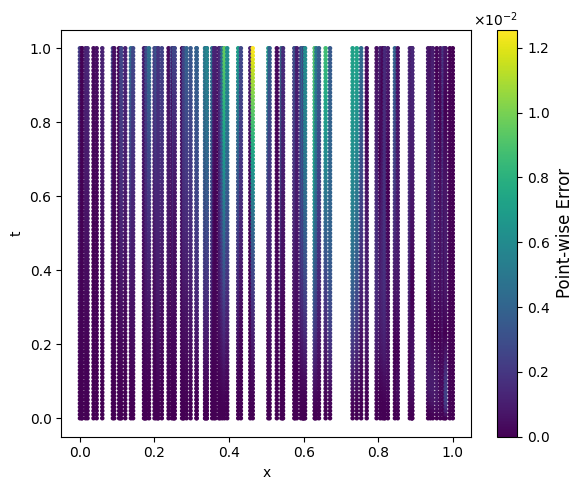

In [12]:
from scipy.io import loadmat

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 10
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 


tau = 1e-2
T = 1
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)[None,:]

data = loadmat('./data/mydata_heat1d_random_sigma2_1e-1.mat')

#'F_0',  'U_0',   'F_new','U_new', 'p','in','bc'
# (M,1), (M,NT),  (M,100), (100,M,NT)
p,F_0,U_0, F_new, U_new, index_in, index_bc = data['p'],data['F_0'],data['U_0'],data['F_new'],data['U_new'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print("U_new.shape,", F_new.shape) # (n_batch,M,NT)

torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]
M1 = M - M2

F_new = np.concatenate([F_new[index_in,:],F_new[index_bc,:]],axis=0)
testnum = 1
Yin,Yb = Y[index_in],Y[index_bc] # interior and boundary points

F_new_train = F_new[:M1,testnum]  # (M1,)
F_new_train = F_new_train.repeat(Nt).reshape(M1, Nt)  # (M1,Nt)
# print(f"F_new_train.shape: {F_new_train.shape},{F_new_train}")


order = 6
K = 30
reg = 1e-14

u_true = U_new[testnum,:,:]
# print(u_true.shape) # (M,NT)
u_true = np.concatenate([u_true[index_in],u_true[index_bc]],axis=0)
# patch settings
# ptch select # 32
ptch, counts = make_1d_patches_scattered(Y, K_avg=K, n_patches=10, overlap_factor=1.1)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================
X = np.concatenate([Yin, Yb], axis=0)
# # ===========================================================
U, LBDF1, LBDF2, LI = rfm_fd_pou_poly_solve_heat_1d(kap,ptch,phi_net,X,Yin,Yb,t,tau,F_new_train,g_func,u0_func,reg,order)

# print("U.shape ",U.shape) #(M,NT)
error = np.abs(U - u_true)
error_inf = np.max(np.max(error))
print(f'p = {order}; L infity error in u_rfmfd_pou: {error_inf:.3e}')
error_l2 = relative_l2(U.ravel(), u_true.ravel())
print(f'p = {order}; Relative L2 error in u_rfmfd_pou: {error_l2:.3e}')

for i in range(Nt):
    err_time = relative_l2(U[:,i], u_true[:,i])
    print(f'Time step {i}, Relative L2 error: {err_time:.3e}')

yy,tt = np.meshgrid(Y, t, indexing='ij')
tt = tt.ravel()
yy = yy.ravel()
e = error.ravel()

plt.figure(figsize=(6,5))
sc = plt.scatter(yy, tt, c = e, cmap='viridis', s=5)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('t')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_error_200_size{M}.eps', bbox_inches='tight')
plt.show()




In [13]:
def build_wls_solver(A, reg=1e-12):
    """
    Precompute WLS system for repeated RHS solves.
    """

    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")

    A = A.tocsr()
    M, N = A.shape

    # -------------------------------------------------
    # weight (computed ONCE)
    # -------------------------------------------------
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 10.0 / (row_max + 1e-12)

    W = sp.diags(w, format='csr')

    # -------------------------------------------------
    # precompute matrices
    # -------------------------------------------------
    Aw = W @ A
    AtA = Aw.T @ Aw + reg * sp.eye(N, format='csr')

    # factorization (FAST SOLVE)
    solver = spla.factorized(AtA.tocsc())

    # -------------------------------------------------
    # return closure
    # -------------------------------------------------
    def solve(RHS):
        """
        RHS: (M,K)
        """
        RHS = np.asarray(RHS, dtype=np.float64)

        if RHS.ndim == 1:
            RHS = RHS[:, None]

        # weighted RHS
        RHSw = w[:, None] * RHS

        Atb = Aw.T @ RHSw
        x = solver(Atb)

        if x.ndim == 1:
            x = x[:, None]

        return x

    return solve

def test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, u0_func,
                Yin, Yb, t, tau,
                scheme="BDF2"):
    """
    Multi-batch heat solver using unified WLS (row-max weighted least squares).

    Returns
    -------
    U : ndarray, shape (n_batch, M, NT)
    """

    # --------------------------------------------------
    # geometry
    # --------------------------------------------------
    Y = np.concatenate([Yin, Yb], axis=0)
    M = Y.shape[0]
    M2 = Yb.shape[0]
    M1 = M - M2
    NT = t.shape[-1]

    # --------------------------------------------------
    # data
    # --------------------------------------------------
    f_val = f_func(Yin, t) if callable(f_func) else f_func  # (n_batch,M1) or (n_batch,M1,Nt) 
    g_val = g_func(Yb, t) if callable(g_func) else g_func   # (M2, Nt)

    u0 = u0_func(Y) if callable(u0_func) else u0_func       # (M,1) 
    u0 = np.asarray(u0, dtype=np.float64)

    # --------------------------------------------------
    # batch handling
    # --------------------------------------------------
    n_batch = f_val.shape[0]
    if f_val.ndim == 2:
        # (n_batch, M1) 
        time_dependent = False
    else:
        # (n_batch, M1, NT)
        time_dependent = True

    solve_LBDF1 = build_wls_solver(LBDF1, reg=1e-12)
    solve_LBDF2 = build_wls_solver(LBDF2, reg=1e-12)
    solve_LI    = build_wls_solver(LI, reg=1e-12)

    # --------------------------------------------------
    # initial solve (LI)
    # --------------------------------------------------
    alpha_0 = solve_LI(u0)

    # --------------------------------------------------
    # storage
    # --------------------------------------------------
    U = np.zeros((n_batch, M, NT), dtype=np.float64)
    U[:, :, 0] = u0.repeat(n_batch).reshape(n_batch, M)
    U[:, M1:, :] = g_val[None, :, :]

    reg = 1e-12

    # ==================================================
    # BDF1
    # ==================================================
    if scheme == "BDF1":

        for i in range(0, NT - 1):

            rhs_int = LI @ alpha_0
            if rhs_int.ndim == 1:
                rhs_int = rhs_int[:, None]

            if time_dependent:
                f_slice = f_val[:, :, i + 1]        # (n_batch, M1)
            else:
                f_slice = f_val                     # (n_batch, M1)
            rhs = rhs_int[:M1, :] + tau * f_slice.T   # (M1, n_batch)

            RHS = np.vstack([
                rhs,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_1, _ = solve_LBDF1(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_1).T

            alpha_0 = alpha_1

        return U
    # ==================================================
    # BDF2
    # ==================================================
    elif scheme == "BDF2":

        # -----------------------------
        # step 1: initial BDF1 step
        # -----------------------------
        if time_dependent:
            f_slice = f_val[:, :, 1]        # (n_batch, M1)
        else:
            f_slice = f_val                     # (n_batch, M1)
        rhs_int = LI[:M1, :] @ alpha_0 + tau * f_slice.T   # (M1, n_batch)

        RHS = np.vstack([
            rhs_int,
            np.repeat(g_val[:, 1:2], n_batch, axis=1)
        ])

        alpha_1 = solve_LBDF1(RHS)

        U[:, :M1, 1] = (LI[:M1, :] @ alpha_1).T

        # -----------------------------
        # BDF2 time loop
        # -----------------------------
        for i in range(1, NT - 1):
            if time_dependent:
                f_slice = f_val[:, :, i + 1]        # (n_batch, M1)
            else:
                f_slice = f_val                     # (n_batch, M1)

            rhs_int = (
                LI[:M1, :] @ (4 * alpha_1 - alpha_0)
                + 2 * tau * f_slice.T
            )

            RHS = np.vstack([
                rhs_int,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_2 = solve_LBDF2(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_2).T
            U[:, M1:, i + 1] = g_val[:, i + 1]

            alpha_0 = alpha_1
            alpha_1 = alpha_2

        return U

    else:
        raise ValueError("Unsupported scheme. Use 'BDF1' or 'BDF2'.")

U_new.shape  (100, 101, 101)
After reordering, U_new.shape  (100, 101, 101)
p = 6, inference time: 0.0849 秒
error_L2.shape: (100, 1), error.shape: (100, 101, 101)
p = 6, test on 100 samples. The mean of max error: 1.910747e-02, and mean of relative L2 error: 9.443601e-03
p = 6, test on 100 samples. The variance of max error: 6.897192e-05, and variance of relative L2 error: 1.569344e-05


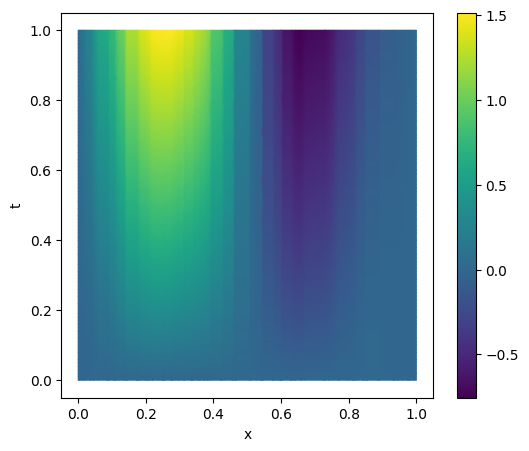

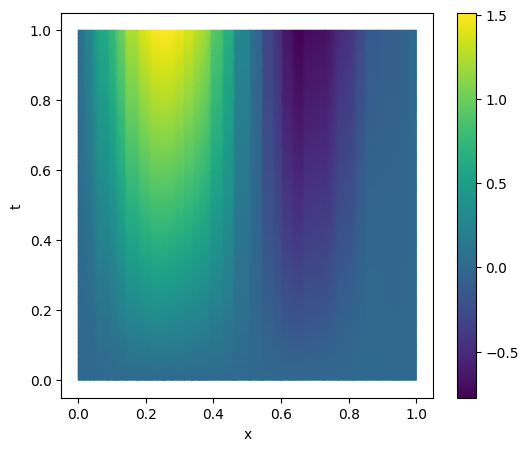

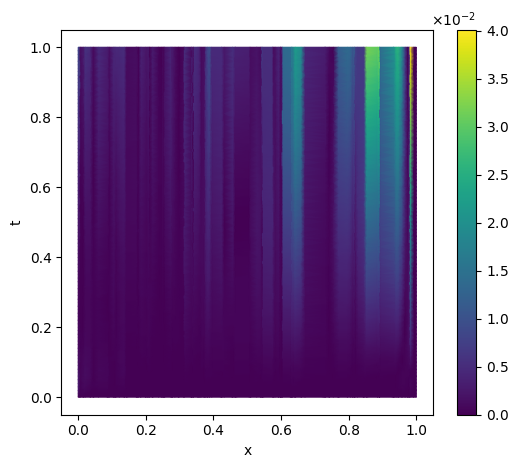

In [14]:
import time

E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points

# (M1, n_batch) -> (n_batch,M1,Nt) 
F_new_test = F_new[:M1,:].T  # (100,M1)

u_true = U_new # (100,M,NT)
print( "U_new.shape ", u_true.shape) 
u_true = np.concatenate([u_true[:,index_in,:],u_true[:,index_bc,:]], axis=1)
print("After reordering, U_new.shape ", U_new.shape) #(M,100)


start_time = time.time()
UY = test_solver(LBDF1, LBDF2, LI,
                F_new_test, g_func, u0_func,
                Yin, Yb, t, tau,
                scheme="BDF2")

end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")

error = np.abs(UY - u_true) # (n_batch, M, NT)
E_inf =  np.max(np.max(error, axis=2), axis=1) # (n_batch, 1)
# print(E_inf)

error_L2 = (np.linalg.norm(UY - u_true, axis=(1,2)) / np.linalg.norm(u_true, axis=(1,2)))[:, None] # (n_batch, 1)
print(f"error_L2.shape: {error_L2.shape}, error.shape: {error.shape}") #(n_batch,1), (n_batch,M,NT)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")

np.random.seed(30)
q = np.random.randint(0, 100)
u_true_q = u_true[q,:,:].ravel()
UY_q = UY[q,:,:].ravel()
error_q = error[q,:,:].ravel()

plt.figure(figsize=(6,5))
# sc = plt.scatter(yy, tt, c = u_true_q, cmap='viridis', s=10)
sc = plt.tripcolor(yy, tt, u_true_q, shading='gouraud', cmap='viridis')
plt.colorbar(sc)
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('t')
plt.savefig(f'./result/heat1d_random_rfmfd_pou_p={order}_u_fem_one_test_sample.eps', bbox_inches='tight')
plt.show()
plt.figure(figsize=(6,5))
# sc = plt.scatter(yy, tt, c = UY_q, cmap='viridis', s=10)
sc = plt.tripcolor(yy, tt, UY_q, shading='gouraud', cmap='viridis')


plt.colorbar(sc)
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('t')
plt.savefig(f'./result/heat1d_random_rfmfd_pou_p={order}_UY_one_test_sample.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
# sc = plt.scatter(yy, tt, c = error_q, cmap='viridis', s=5)
sc = plt.tripcolor(yy, tt, error_q, shading='gouraud', cmap='viridis')

cbar = plt.colorbar(sc)
# cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Argumented RFM-FD\' point wise error with {order} order polynomial')
plt.xlabel('x')
plt.ylabel('t')
plt.savefig(f'./result/heat1d_random_rfmfd_pou_p={order}_error_one_test_sample.eps', bbox_inches='tight')
plt.show()



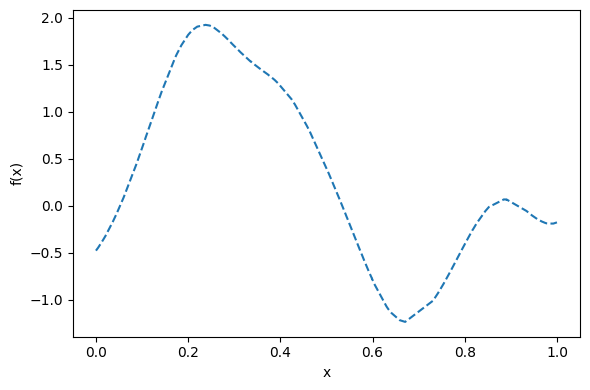

In [7]:
F_new_test_q= F_new[:,q].ravel()
F_new_test_q.shape[0]
idx = np.argsort(X.ravel())
xx = X[idx]
yy = F_new_test_q[idx]

plt.figure(figsize=(6,4))
plt.plot(xx, yy, '--', markersize=3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.tight_layout()
plt.show()

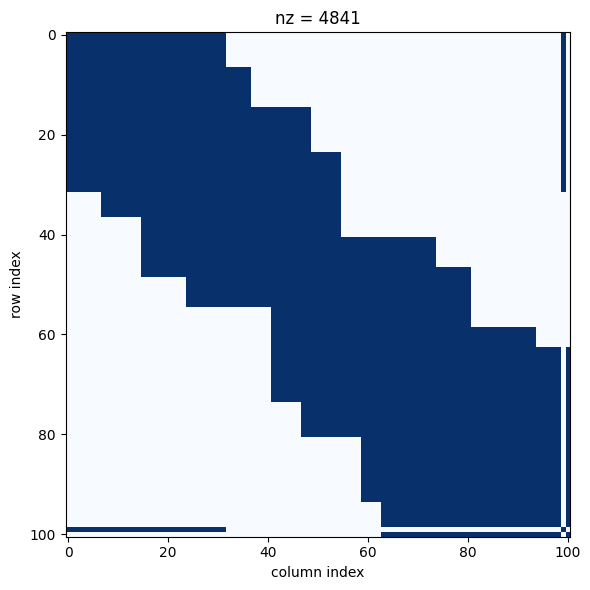

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    # plt.savefig('L.eps', bbox_inches='tight')
    plt.show()
spy_like_matlab(LBDF2)

In [9]:
# for name, param in Phi.named_parameters():
#     print(name, param.data)

In [10]:
import numpy as np

data = np.array([
    0.021994969063378098,
    0.04911251337641761,
    0.01650726619461412,
    0.08837556357700145,
    0.009211639675363155,
    0.0277817841807126,
    0.015015518759205742,
    0.02150212915581012,
    0.022161040436164403,
    0.016821863493068048
])

# mean
mean = np.mean(data)

# population variance (ddof=0)
var_pop = np.var(data)

# sample variance (ddof=1)
var_sample = np.var(data, ddof=1)

print("mean =", mean)
print("population variance =", var_pop)
print("sample variance =", var_sample)

mean = 0.028848428791173532
population variance = 0.000497480527603248
sample variance = 0.0005527561417813866
